# Shoelace Artifact â€” All-Positive Pixel Jdet, Folded Quad Cell

This notebook constructs a small DVF where every **pixel** Jacobian determinant (central-difference stencil, `jacobian_det2D`) is strictly positive â€” yet one quad cell of the deformed grid has a **negative shoelace area**, i.e. it is folded into a bowtie.

Central differences sample a pixel's horizontal/vertical neighbours one step away, so a perturbation at a single pixel is averaged across 2Î”. The shoelace formula, by contrast, uses the four corners of a quad directly, so it captures the true signed geometric area. The two measures can â€” and do â€” disagree.

We verify the artifact with two complementary diagnostics:

1. **Injectivity metric** â€” forward-difference monotonicity of the deformed coordinates (`_monotonicity_diffs_2d` + diagonal diffs). All four diffs must stay positive for the deformed grid to be globally injective.
2. **Neighborhood measure** â€” sub-pixel injectivity certificates from `cell_min_jdet_2d` (bilinear quad minimum) and `ift_radius_2d` (quantitative IFT radius).

Both should flag the folded cell that the central-difference Jdet misses.

<a id="sec-toc"></a>
## Table of contents

1. [Construction](#sec-construction)
2. [Visualisation on the DVF quad grid](#sec-viz)
3. [Manual proof — central-diff Jdet is positive at the four shoelace vertices](#sec-manual-proof)
4. [Verification 1 — Injectivity metric (monotonicity)](#sec-injectivity)
5. [Verification 2 — Neighborhood measure](#sec-neighborhood)
    - [The IFT radius formula](#sec-ift-formula)
6. [Correction — optimise for positive Jdet and positive shoelace](#sec-correction)
    - [Re-quantify the corrected field](#sec-requantify)
    - [Before / after — quad grid and diagnostic heatmaps](#sec-beforeafter)
7. [Strengthening — triangulated shoelace closes the bowtie loophole](#sec-triangulated)
    - [Diagonal-split intuition](#sec-tri-intuition)
    - [Re-quantify the triangulated correction](#sec-tri-requantify)
    - [Before / after — triangulated](#sec-tri-beforeafter)
8. [Summary](#sec-summary)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Polygon

from dvfopt import jacobian_det2D, shoelace_det2D
from dvfopt.jacobian.monotonicity import (
    _monotonicity_diffs_2d,
    _diagonal_monotonicity_diffs_2d,
)
from dvfopt.jacobian.injectivity_radius import (
    ift_radius_2d,
    cell_min_jdet_2d,
)

<a id="sec-construction"></a>
## Construction

On a 7Ã—7 grid, set two adjacent interior pixels to opposite horizontal displacements:

```
dx[3, 3] = +a,    dx[3, 4] = -a,    a = 1.2
```

All other displacements (including the entire `dy` channel) are zero.

**Why this works:** At pixel (3, 3), `np.gradient` computes `âˆ‚dx/âˆ‚x = (dx[3,4] âˆ’ dx[3,2]) / 2 = âˆ’0.6`, so Jdet = 1 âˆ’ 0.6 = 0.4 > 0. The same argument applies at (3, 4). Every pixel-Jdet is positive. But the quad with top-left at (3, 3) has deformed corners

```
TL = (3, 4.2)   TR = (3, 2.8)
BL = (4, 3.0)   BR = (4, 4.0)
```

TL lies to the right of TR â€” the top edge has crossed itself, so the shoelace area is negative.

[â†‘ Back to TOC](#sec-toc)

In [2]:
H, W = 7, 7
a = 1.2

dy = np.zeros((H, W))
dx = np.zeros((H, W))
dx[3, 3] = +a
dx[3, 4] = -a

phi = np.stack([dy, dx])                        # (2, H, W)
deformation = np.zeros((3, 1, H, W))            # (3, 1, H, W) â€” dz, dy, dx
deformation[1, 0] = dy
deformation[2, 0] = dx

print(f"phi shape        : {phi.shape}")
print(f"deformation shape: {deformation.shape}")
print(f"Nonzero pixels   : {np.count_nonzero(dx)} (in dx)")

phi shape        : (2, 7, 7)
deformation shape: (3, 1, 7, 7)
Nonzero pixels   : 2 (in dx)


In [3]:
jdet = np.squeeze(jacobian_det2D(phi))          # (H, W)
shoe = np.squeeze(shoelace_det2D(phi))          # (H-1, W-1)

n_neg_jdet = int((jdet <= 0).sum())
n_neg_shoe = int((shoe <= 0).sum())

print(f"Pixel Jdet  : min = {jdet.min():+.4f}   neg count = {n_neg_jdet}")
print(f"Shoelace    : min = {shoe.min():+.4f}   neg count = {n_neg_shoe}")

neg_cells = np.argwhere(shoe <= 0)
print(f"\nFolded quad cells (TL corner index): {[tuple(ij) for ij in neg_cells]}")

assert n_neg_jdet == 0, "expected all pixel-Jdets positive"
assert n_neg_shoe > 0, "expected at least one negative shoelace cell"

Pixel Jdet  : min = +0.4000   neg count = 0
Shoelace    : min = -0.2000   neg count = 2

Folded quad cells (TL corner index): [(np.int64(2), np.int64(3)), (np.int64(3), np.int64(3))]


<a id="sec-viz"></a>
## Visualisation on the DVF quad grid

Each measure is drawn where it actually lives:

* **Shoelace area** is a *per-quad* quantity (signed area of each quad polygon), so the left panel fills quads with the shoelace colormap. The folded cell is outlined in yellow.
* **Central-difference pixel Jdet** is a *per-vertex* quantity â€” one value at each grid pixel. It does **not** naturally attach to a quad (a quad lives *between* four pixels). To avoid a misleading per-quad fill, the right panel draws the quads as a neutral wireframe and colours the **deformed vertices themselves** by their Jdet values.

Each deformed vertex is labelled with its original grid index `(i, j)`. The two moved pixels (shown in bold red labels) are `(3, 3)` and `(3, 4)`; in the deformed grid `(3, 4)` ends up drawn to the **left** of `(3, 3)`, because `dx[3, 3] = +1.2` pushes (3, 3) rightward and `dx[3, 4] = âˆ’1.2` pulls (3, 4) leftward. That horizontal swap is the bowtie â€” and every vertex scatter-point stays in the positive half of the colormap, which is exactly why the pixel Jdet misses it.

[â†‘ Back to TOC](#sec-toc)

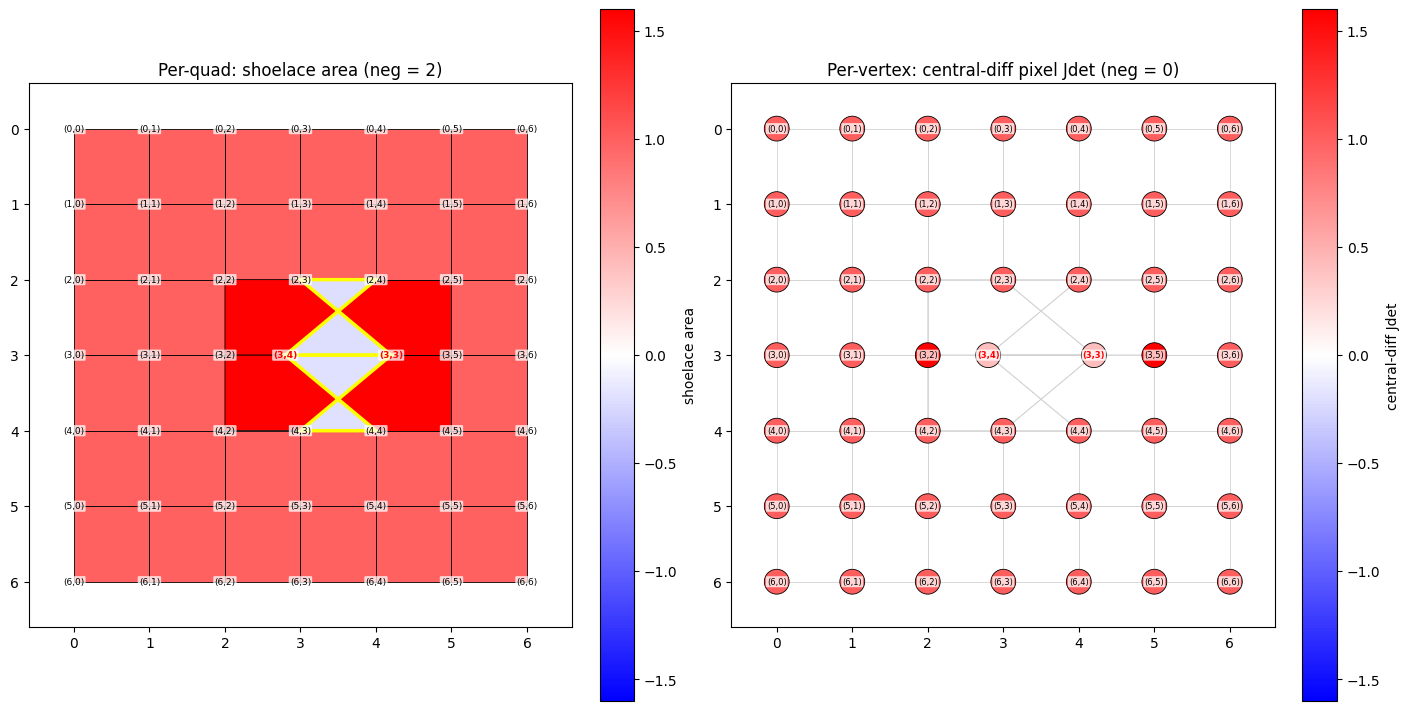

In [4]:
yy, xx = np.mgrid[0:H, 0:W].astype(float)
def_y = yy + dy
def_x = xx + dx


def _annotate_vertices(ax, def_x, def_y, fontsize=6.5):
    """Label each deformed vertex with its original grid index (i, j)."""
    H_, W_ = def_x.shape
    for i in range(H_):
        for j in range(W_):
            moved = (dx[i, j] != 0) or (dy[i, j] != 0)
            ax.text(def_x[i, j], def_y[i, j], f"({i},{j})",
                    ha="center", va="center",
                    fontsize=fontsize,
                    color="red" if moved else "black",
                    fontweight="bold" if moved else "normal",
                    bbox=dict(boxstyle="round,pad=0.12",
                              facecolor="white", edgecolor="none", alpha=0.75),
                    zorder=5)


fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)
cmap = plt.get_cmap("bwr")

# --- Left: per-quad shoelace area (fills quads â€” shoelace is per-cell) --
ax = axes[0]
vmax_s = max(abs(shoe.min()), abs(shoe.max()), 1.0)
norm_s = mcolors.TwoSlopeNorm(vmin=-vmax_s, vcenter=0, vmax=vmax_s)

for i in range(H - 1):
    for j in range(W - 1):
        corners = [
            (def_x[i, j],         def_y[i, j]),
            (def_x[i, j + 1],     def_y[i, j + 1]),
            (def_x[i + 1, j + 1], def_y[i + 1, j + 1]),
            (def_x[i + 1, j],     def_y[i + 1, j]),
        ]
        folded = shoe[i, j] <= 0
        ax.add_patch(Polygon(
            corners, closed=True,
            facecolor=cmap(norm_s(shoe[i, j])),
            edgecolor="yellow" if folded else "black",
            linewidth=2.5 if folded else 0.6,
            zorder=2 if folded else 1,
        ))

_annotate_vertices(ax, def_x, def_y)
ax.set_xlim(def_x.min() - 0.6, def_x.max() + 0.6)
ax.set_ylim(def_y.max() + 0.6, def_y.min() - 0.6)
ax.set_aspect("equal")
ax.set_title(f"Per-quad: shoelace area (neg = {n_neg_shoe})")
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_s), ax=ax,
             label="shoelace area")

# --- Right: per-vertex pixel Jdet (scatter â€” Jdet lives at pixels) ------
ax = axes[1]
vmax_j = max(abs(jdet.min()), abs(jdet.max()), 1.0)
norm_j = mcolors.TwoSlopeNorm(vmin=-vmax_j, vcenter=0, vmax=vmax_j)

for i in range(H - 1):
    for j in range(W - 1):
        corners = [
            (def_x[i, j],         def_y[i, j]),
            (def_x[i, j + 1],     def_y[i, j + 1]),
            (def_x[i + 1, j + 1], def_y[i + 1, j + 1]),
            (def_x[i + 1, j],     def_y[i + 1, j]),
        ]
        ax.add_patch(Polygon(corners, closed=True,
                             facecolor="none", edgecolor="lightgray",
                             linewidth=0.6, zorder=1))

sc = ax.scatter(def_x.ravel(), def_y.ravel(),
                c=jdet.ravel(), cmap=cmap, norm=norm_j,
                s=320, edgecolor="k", linewidth=0.6, zorder=3)
_annotate_vertices(ax, def_x, def_y, fontsize=6)

ax.set_xlim(def_x.min() - 0.6, def_x.max() + 0.6)
ax.set_ylim(def_y.max() + 0.6, def_y.min() - 0.6)
ax.set_aspect("equal")
ax.set_title(f"Per-vertex: central-diff pixel Jdet (neg = {n_neg_jdet})")
plt.colorbar(sc, ax=ax, label="central-diff Jdet")

plt.show()

<a id="sec-manual-proof"></a>
## Manual proof — central-diff Jdet is positive at the four shoelace vertices

Computing `jacobian_det2D` by hand at each of the four corners of the bowtie cell (TL = (3, 3), TR = (3, 4), BR = (4, 4), BL = (4, 3)):

```
Jdet(i, j) = (1 + ∂dx/∂x)(1 + ∂dy/∂y) − (∂dx/∂y)(∂dy/∂x)
```

with interior central differences

```
∂f/∂x at (i, j) = (f[i, j+1] − f[i, j-1]) / 2
∂f/∂y at (i, j) = (f[i+1, j] − f[i-1, j]) / 2
```

The central stencil samples a pixel's neighbours one step away on each side, so a perturbation at a single pixel is averaged across 2Δ. At pixel (3, 3), for example, `∂dx/∂x = (dx[3, 4] − dx[3, 2]) / 2 = (−1.2 − 0) / 2 = −0.6`, giving `Jdet = 1 + (−0.6) = 0.4 > 0` — the central stencil never even sees `dx[3, 3] = +1.2`, so the bowtie is invisible to it.

The cell below walks through the arithmetic for all four vertices and cross-checks the result against `numpy.gradient`.

[↑ Back to TOC](#sec-toc)

In [5]:
def cdiff_jdet(label, i, j):
    dxdx = (dx[i, j + 1] - dx[i, j - 1]) / 2
    dxdy = (dx[i + 1, j] - dx[i - 1, j]) / 2
    dydx = (dy[i, j + 1] - dy[i, j - 1]) / 2
    dydy = (dy[i + 1, j] - dy[i - 1, j]) / 2
    det = (1 + dxdx) * (1 + dydy) - dxdy * dydx
    print(f"  {label}  pixel ({i}, {j})")
    print(f"    dx/dx = (dx[{i},{j+1}] - dx[{i},{j-1}]) / 2 "
          f"= ({dx[i, j+1]:+.1f} - {dx[i, j-1]:+.1f}) / 2 = {dxdx:+.4f}")
    print(f"    dx/dy = (dx[{i+1},{j}] - dx[{i-1},{j}]) / 2 "
          f"= ({dx[i+1, j]:+.1f} - {dx[i-1, j]:+.1f}) / 2 = {dxdy:+.4f}")
    print(f"    dy/dx = (dy[{i},{j+1}] - dy[{i},{j-1}]) / 2 "
          f"= ({dy[i, j+1]:+.1f} - {dy[i, j-1]:+.1f}) / 2 = {dydx:+.4f}")
    print(f"    dy/dy = (dy[{i+1},{j}] - dy[{i-1},{j}]) / 2 "
          f"= ({dy[i+1, j]:+.1f} - {dy[i-1, j]:+.1f}) / 2 = {dydy:+.4f}")
    print(f"    Jdet  = ({1+dxdx:+.4f}) * ({1+dydy:+.4f}) "
          f"- ({dxdy:+.4f}) * ({dydx:+.4f})  =  {det:+.4f}")
    print()
    return det


print("Central-difference Jdet at the four vertices of the folded quad cell:\n")
j_tl = cdiff_jdet("TL", 3, 3)
j_tr = cdiff_jdet("TR", 3, 4)
j_br = cdiff_jdet("BR", 4, 4)
j_bl = cdiff_jdet("BL", 4, 3)

vals = (j_tl, j_tr, j_br, j_bl)
print(f"All four vertices strictly positive : {all(v > 0 for v in vals)}  "
      f"(values: {[round(v, 4) for v in vals]})")
print("Match np.gradient output            :",
      np.isclose(j_tl, jdet[3, 3]) and np.isclose(j_tr, jdet[3, 4])
      and np.isclose(j_br, jdet[4, 4]) and np.isclose(j_bl, jdet[4, 3]))

assert all(v > 0 for v in vals), "central-diff Jdet should be positive at every shoelace vertex"


Central-difference Jdet at the four vertices of the folded quad cell:

  TL  pixel (3, 3)
    dx/dx = (dx[3,4] - dx[3,2]) / 2 = (-1.2 - +0.0) / 2 = -0.6000
    dx/dy = (dx[4,3] - dx[2,3]) / 2 = (+0.0 - +0.0) / 2 = +0.0000
    dy/dx = (dy[3,4] - dy[3,2]) / 2 = (+0.0 - +0.0) / 2 = +0.0000
    dy/dy = (dy[4,3] - dy[2,3]) / 2 = (+0.0 - +0.0) / 2 = +0.0000
    Jdet  = (+0.4000) * (+1.0000) - (+0.0000) * (+0.0000)  =  +0.4000

  TR  pixel (3, 4)
    dx/dx = (dx[3,5] - dx[3,3]) / 2 = (+0.0 - +1.2) / 2 = -0.6000
    dx/dy = (dx[4,4] - dx[2,4]) / 2 = (+0.0 - +0.0) / 2 = +0.0000
    dy/dx = (dy[3,5] - dy[3,3]) / 2 = (+0.0 - +0.0) / 2 = +0.0000
    dy/dy = (dy[4,4] - dy[2,4]) / 2 = (+0.0 - +0.0) / 2 = +0.0000
    Jdet  = (+0.4000) * (+1.0000) - (+0.0000) * (+0.0000)  =  +0.4000

  BR  pixel (4, 4)
    dx/dx = (dx[4,5] - dx[4,3]) / 2 = (+0.0 - +0.0) / 2 = +0.0000
    dx/dy = (dx[5,4] - dx[3,4]) / 2 = (+0.0 - -1.2) / 2 = +0.6000
    dy/dx = (dy[4,5] - dy[4,3]) / 2 = (+0.0 - +0.0) / 2 = +0.0000
    

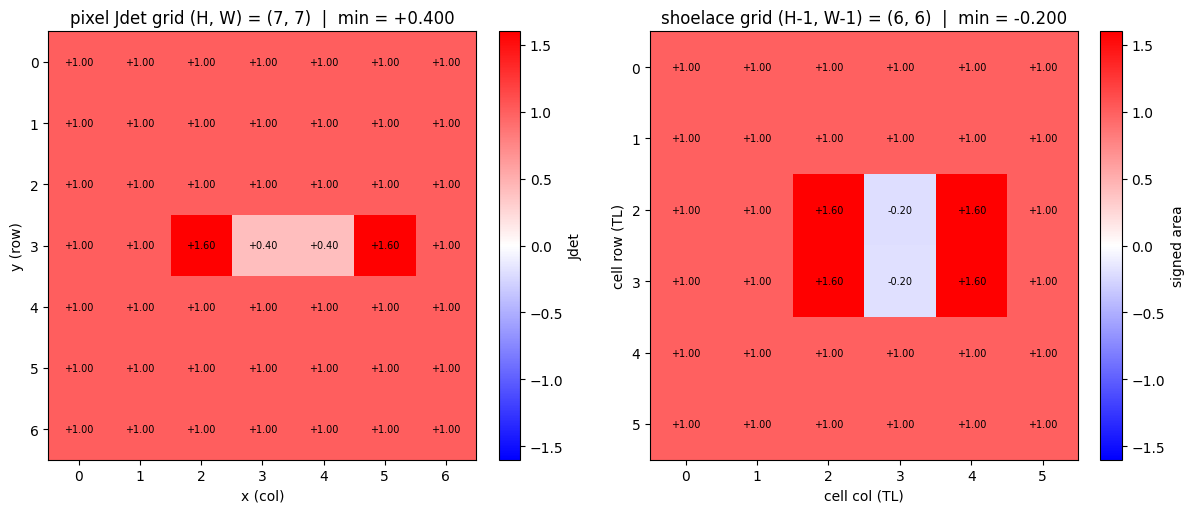

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

vmax_j = max(abs(jdet.min()), abs(jdet.max()), 1.0)
norm_j = mcolors.TwoSlopeNorm(vmin=-vmax_j, vcenter=0, vmax=vmax_j)
im0 = axes[0].imshow(jdet, cmap="bwr", norm=norm_j)
axes[0].set_title(f"pixel Jdet grid (H, W) = {jdet.shape}  |  min = {jdet.min():+.3f}")
axes[0].set_xlabel("x (col)")
axes[0].set_ylabel("y (row)")
for (i, j), v in np.ndenumerate(jdet):
    axes[0].text(j, i, f"{v:+.2f}", ha="center", va="center",
                 fontsize=7, color="black")
plt.colorbar(im0, ax=axes[0], label="Jdet")

vmax_s = max(abs(shoe.min()), abs(shoe.max()), 1.0)
norm_s = mcolors.TwoSlopeNorm(vmin=-vmax_s, vcenter=0, vmax=vmax_s)
im1 = axes[1].imshow(shoe, cmap="bwr", norm=norm_s)
axes[1].set_title(f"shoelace grid (H-1, W-1) = {shoe.shape}  |  min = {shoe.min():+.3f}")
axes[1].set_xlabel("cell col (TL)")
axes[1].set_ylabel("cell row (TL)")
for (i, j), v in np.ndenumerate(shoe):
    axes[1].text(j, i, f"{v:+.2f}", ha="center", va="center",
                 fontsize=7, color="black")
plt.colorbar(im1, ax=axes[1], label="signed area")

plt.show()

<a id="sec-injectivity"></a>
## Verification 1 â€” Injectivity metric (monotonicity)

Global injectivity of the deformed grid requires four forward-difference monotonicity conditions to stay positive:

* `h_mono[r, c] = 1 + dx[r, c+1] âˆ’ dx[r, c]` â€” horizontal ordering preserved
* `v_mono[r, c] = 1 + dy[r+1, c] âˆ’ dy[r, c]` â€” vertical ordering preserved
* `d1[r, c] = 1 + dx[r, c+1] âˆ’ dx[r+1, c]` â€” TR.x > BL.x
* `d2[r, c] = 1 + dy[r+1, c] âˆ’ dy[r, c+1]` â€” BL.y > TR.y

Any non-positive value flags a folded cell.

[â†‘ Back to TOC](#sec-toc)

In [7]:
h_mono, v_mono = _monotonicity_diffs_2d(dy, dx)
d1, d2 = _diagonal_monotonicity_diffs_2d(dy, dx)

def _report(name, m):
    n_bad = int((m <= 0).sum())
    print(f"  {name:<8s}  shape={m.shape}  min={m.min():+.4f}  non-positive={n_bad}")
    if n_bad:
        for ij in np.argwhere(m <= 0):
            r, c = int(ij[0]), int(ij[1])
            print(f"       -> ({r}, {c}) = {m[r, c]:+.4f}")

print("Monotonicity diffs:")
_report("h_mono", h_mono)
_report("v_mono", v_mono)
_report("d1",     d1)
_report("d2",     d2)

any_bad = any((m <= 0).any() for m in (h_mono, v_mono, d1, d2))
print(f"\nInjectivity metric flags fold: {any_bad}")
assert any_bad, "injectivity metric should detect the bowtie"

Monotonicity diffs:
  h_mono    shape=(7, 6)  min=-1.4000  non-positive=1
       -> (3, 3) = -1.4000
  v_mono    shape=(6, 7)  min=+1.0000  non-positive=0
  d1        shape=(6, 6)  min=-0.2000  non-positive=2
       -> (2, 3) = -0.2000
       -> (3, 3) = -0.2000
  d2        shape=(6, 6)  min=+1.0000  non-positive=0

Injectivity metric flags fold: True


<a id="sec-neighborhood"></a>
## Verification 2 — Neighborhood measure

* `cell_min_jdet_2d` — closed-form minimum of the bilinear-interpolant Jdet over each unit quad. Positivity ⇒ the continuous deformation is injective over the whole cell (sub-pixel certificate).
* `ift_radius_2d` — quantitative Inverse Function Theorem lower bound on the size of the neighbourhood where the deformation is provably injective. Small values mean the certified-invertible region shrinks toward a point.

<a id="sec-ift-formula"></a>
### The IFT radius formula

We want a **guaranteed-injective ball**: the largest $r$ such that the deformation $\varphi(x) = x + u(x)$ is one-to-one on $B(x_0, r)$. The quantitative inverse-function theorem gives

$$r(x_0) \;\lesssim\; \frac{\sigma_{\min}\bigl(I + \nabla u(x_0)\bigr)}{\lVert \nabla^2 u \rVert_{B(x_0,r)}}.$$

This follows from the fundamental theorem of calculus plus the Neumann / Banach invertibility lemma. Derivation below.

<a id="sec-ift-derivation"></a>
#### Step-by-step derivation

**Step 1 — chord form from the fundamental theorem of calculus.** For any $y, z$ in a convex set, $\varphi(z) - \varphi(y)$ is the integral of its derivative along the segment $\gamma(t) = y + t(z - y)$, $t \in [0, 1]$. Chain rule + FTC give

$$
\varphi(z) - \varphi(y) \;=\; \int_0^1 D\varphi\bigl(y + t(z-y)\bigr)(z - y)\,dt \;=\; \underbrace{\left[\int_0^1 D\varphi\bigl(y + t(z-y)\bigr)\,dt\right]}_{M(y, z)}\,(z - y).
$$

So if $\varphi(z) = \varphi(y)$ with $y \neq z$, then $M(y, z)$ must kill the nonzero vector $z - y$ — i.e. $M(y, z)$ is **singular**. Therefore **$\varphi$ is injective on $B(x_0, r)$ whenever $M(y, z)$ is invertible for every pair in that ball.**

**Step 2 — split $M$ into centre + perturbation.** Add and subtract $D\varphi(x_0)$:

$$
M(y, z) \;=\; D\varphi(x_0) \;+\; \underbrace{\int_0^1 \bigl[\,D\varphi\bigl(y + t(z-y)\bigr) - D\varphi(x_0)\,\bigr]\,dt}_{E(y, z)}.
$$

The "unperturbed" piece $D\varphi(x_0) = I + \nabla u(x_0)$ is exactly what appears in the numerator of the final formula. Everything else is dumped into $E$.

**Step 3 — bound $\lVert E \rVert$ using the Hessian.** Since $D^2 \varphi = D^2 u$, the mean-value theorem applied to $D\varphi$ gives

$$
\bigl\lVert D\varphi(w) - D\varphi(x_0) \bigr\rVert \;\le\; \lVert \nabla^2 u \rVert \cdot \lVert w - x_0 \rVert.
$$

If $y, z \in B(x_0, r)$ then by convexity $y + t(z - y) \in B(x_0, r)$ too, so $\lVert w - x_0 \rVert \le r$ on the whole segment. Plug in and take the sup over the ball:

$$
\lVert E(y, z) \rVert \;\le\; \int_0^1 \lVert \nabla^2 u \rVert \cdot r\, dt \;=\; r \cdot L, \qquad L \;:=\; \sup_{B(x_0, r)} \lVert \nabla^2 u \rVert.
$$

**Step 4 — Neumann / Banach invertibility lemma.** For any square matrix $A$ and perturbation $E$,

$$
\lVert E \rVert \;<\; \sigma_{\min}(A) \quad\Longrightarrow\quad A + E \text{ is invertible}.
$$

(Proof sketch: write $A + E = A(I + A^{-1}E)$. $\lVert A^{-1} E \rVert \le \lVert A^{-1} \rVert \cdot \lVert E \rVert = \lVert E \rVert / \sigma_{\min}(A) < 1$, so $I + A^{-1}E$ is invertible by its Neumann series $\sum_{k \ge 0} (-A^{-1}E)^k$.)

Apply with $A = D\varphi(x_0) = I + \nabla u(x_0)$ and $E = E(y, z)$:

$$
r \cdot L \;<\; \sigma_{\min}\bigl(I + \nabla u(x_0)\bigr) \quad\Longrightarrow\quad M(y, z) \text{ invertible for all } y, z \in B(x_0, r).
$$

**Step 5 — solve for $r$.** Rearranging gives the **sharp quantitative-IFT radius**:

$$
r \;<\; \frac{\sigma_{\min}\bigl(I + \nabla u(x_0)\bigr)}{\sup_{B(x_0, r)} \lVert \nabla^2 u \rVert}.
$$

Pointwise (take the sup shrinking to $\lVert \nabla^2 u(x_0) \rVert$ as $r \to 0$), this is the formula evaluated by `ift_radius_2d`. A conservative **factor of $\tfrac{1}{2}$** is often added — this is the contraction-mapping convention, which asks $\lVert E \rVert \le \tfrac{1}{2}\sigma_{\min}(A)$ so the contraction constant stays at most $1/2$, buying quantitative control on $\varphi^{-1}$ in addition to mere invertibility.

**What each term measures, in one line:**

* $\sigma_{\min}(I + \nabla u)$ — how far the linearised Jacobian is from being singular (large ⇒ strongly invertible at $x_0$).
* $\lVert \nabla^2 u \rVert$ — how fast the map deviates from that linearisation (the curvature of the displacement).
* $r$ — radius on which the linear part *still dominates* the curvature term, so no two distinct points collapse onto the same image.

**Why this complements pixel Jdet.** The pixel Jacobian determinant only certifies that the map is non-degenerate *at a point*. The IFT radius says *how far* that certificate extends before curvature could flip the sign. In our bowtie example the cell-min Jdet should go non-positive exactly on the folded cell, and the IFT radius should collapse there.

<a id="sec-ift-discrete"></a>
### How `ift_radius_2d` discretises the formula

The continuous bound above is evaluated pointwise on the grid by [`dvfopt.jacobian.injectivity_radius.ift_radius_2d`](../dvfopt/jacobian/injectivity_radius.py#L65). Given a displacement field with channels $(dy, dx)$ of shape $(H, W)$, it returns a per-pixel `(H, W)` radius map in three steps:

1. **Jacobian $I + \nabla u$ from central differences.** Four partials per pixel are computed with `np.gradient` (interior: second-order central; boundaries: first-order forward/backward):

$$
I + \nabla u \;=\; \begin{pmatrix} 1 + \partial_x dx & \partial_y dx \\[2pt] \partial_x dy & 1 + \partial_y dy \end{pmatrix}.
$$

   These are exactly the same central-difference stencils that produce the pixel Jdet critiqued earlier — so the IFT map inherits the same smoothing blind-spot on sharp bowties. That is by design: both maps are about the *linearised* differential, and the IFT map catches what the Jdet misses via its *denominator*, not its numerator.

2. **Smallest singular value in closed form.** The subscript $F$ is the **Frobenius norm** — square every entry, sum, square-root. For $J = \bigl(\begin{smallmatrix} a & b \\ c & d \end{smallmatrix}\bigr)$, $\lVert J \rVert_F^2 = a^2 + b^2 + c^2 + d^2$.

   Every $2 \times 2$ matrix has two singular values $\sigma_{\min} \le \sigma_{\max}$ satisfying two identities:

$$
\sigma_{\min}\,\sigma_{\max} \;=\; \lvert \det J \rvert, \qquad \sigma_{\min}^2 + \sigma_{\max}^2 \;=\; \lVert J \rVert_F^2.
$$

   So $\sigma_{\min}^2$ and $\sigma_{\max}^2$ are the two roots of $t^2 - \lVert J \rVert_F^2\,t + (\det J)^2 = 0$. The quadratic formula picks the smaller root:

$$
\sigma_{\min}^2 \;=\; \tfrac{1}{2}\Bigl(\lVert J \rVert_F^2 - \sqrt{\lVert J \rVert_F^4 - 4\,(\det J)^2}\Bigr).
$$

   In code this is just four arithmetic steps (see [`_sigma_min_2d`](../dvfopt/jacobian/injectivity_radius.py#L36)):

   ```python
   det       = a*d - b*c
   frob_sq   = a*a + b*b + c*c + d*d
   disc      = frob_sq**2 - 4 * det**2
   sigma_min = np.sqrt(0.5 * (frob_sq - np.sqrt(disc)))
   ```

   No SVD call — one vectorised expression over the whole $(H, W)$ grid. `np.clip(..., 0, None)` inside both `sqrt`s guards against tiny negative values from floating-point noise.

3. **Hessian norm from nested `np.gradient`.** The six independent second partials are formed by applying `np.gradient` twice (once along each axis of the first derivative):

$$
\lVert \nabla^2 u \rVert \;=\; \sqrt{(\partial_{xx} dx)^2 + (\partial_{xy} dx)^2 + (\partial_{yy} dx)^2 + (\partial_{xx} dy)^2 + (\partial_{xy} dy)^2 + (\partial_{yy} dy)^2}.
$$

   This is a 3-point stencil applied twice, so the effective support is a 5-point row/column window — large enough that the denominator *does* see the bowtie's sharp twist even when the central-diff Jacobian smooths it away. That asymmetry is what makes the IFT radius collapse at the fold while the pixel Jdet stays positive.

4. **Per-pixel radius.** The returned array is

$$
r[i, j] \;=\; \frac{\sigma_{\min}(I + \nabla u)[i, j]}{2\,\lVert \nabla^2 u \rVert[i, j] + \varepsilon},\qquad \varepsilon = 10^{-8},
$$

   with $\varepsilon$ keeping the map finite in constant-Jacobian regions where the true radius is $+\infty$ (there, $r$ saturates at $\sigma_{\min}/(2\varepsilon)$, which is effectively "huge — no nearby fold"). The heatmap plotted above is this array rendered with a log-scaled colourbar, so the bowtie cell appears as the dark spot where $r$ drops by several orders of magnitude.

**Practical reading.** Pixels with $r$ near machine-huge are surrounded by a guaranteed-injective ball of radius $\gtrsim r$; pixels where $r$ approaches zero are on (or next to) a fold, where no finite injective neighbourhood can be certified. In the bowtie example the ratio collapses on the self-intersecting quad, consistent with the fold diagnosis from `cell_min_jdet_2d`.

[Back to TOC](#sec-toc)

In [8]:
cell_min = cell_min_jdet_2d(phi)                 # (H-1, W-1)
ift_r    = ift_radius_2d(phi)                    # (H, W)

n_bad_cells = int((cell_min <= 0).sum())
print(f"cell_min_jdet : min = {cell_min.min():+.4f}   non-positive cells = {n_bad_cells}")
for ij in np.argwhere(cell_min <= 0):
    r, c = int(ij[0]), int(ij[1])
    print(f"    -> cell ({r}, {c})  cell_min = {cell_min[r, c]:+.4f}")

# `ift_radius_2d` returns 1/eps (~1e8) in constant-field regions; cap for display.
ift_r_finite = ift_r[ift_r < 1e4]
print(f"\nift_radius    : min = {ift_r.min():.4f}   "
      f"max (finite) = {ift_r_finite.max() if ift_r_finite.size else float('nan'):.4f}")
print(f"  location of minimum (row, col): "
      f"{tuple(int(v) for v in np.unravel_index(ift_r.argmin(), ift_r.shape))}")
ift_display = np.clip(ift_r, 0, 5.0)             # cap for visualisation

cell_min_jdet : min = -1.4000   non-positive cells = 2
    -> cell (2, 3)  cell_min = -1.4000
    -> cell (3, 3)  cell_min = -1.4000

ift_radius    : min = 0.2357   max (finite) = 1.6667
  location of minimum (row, col): (3, 3)


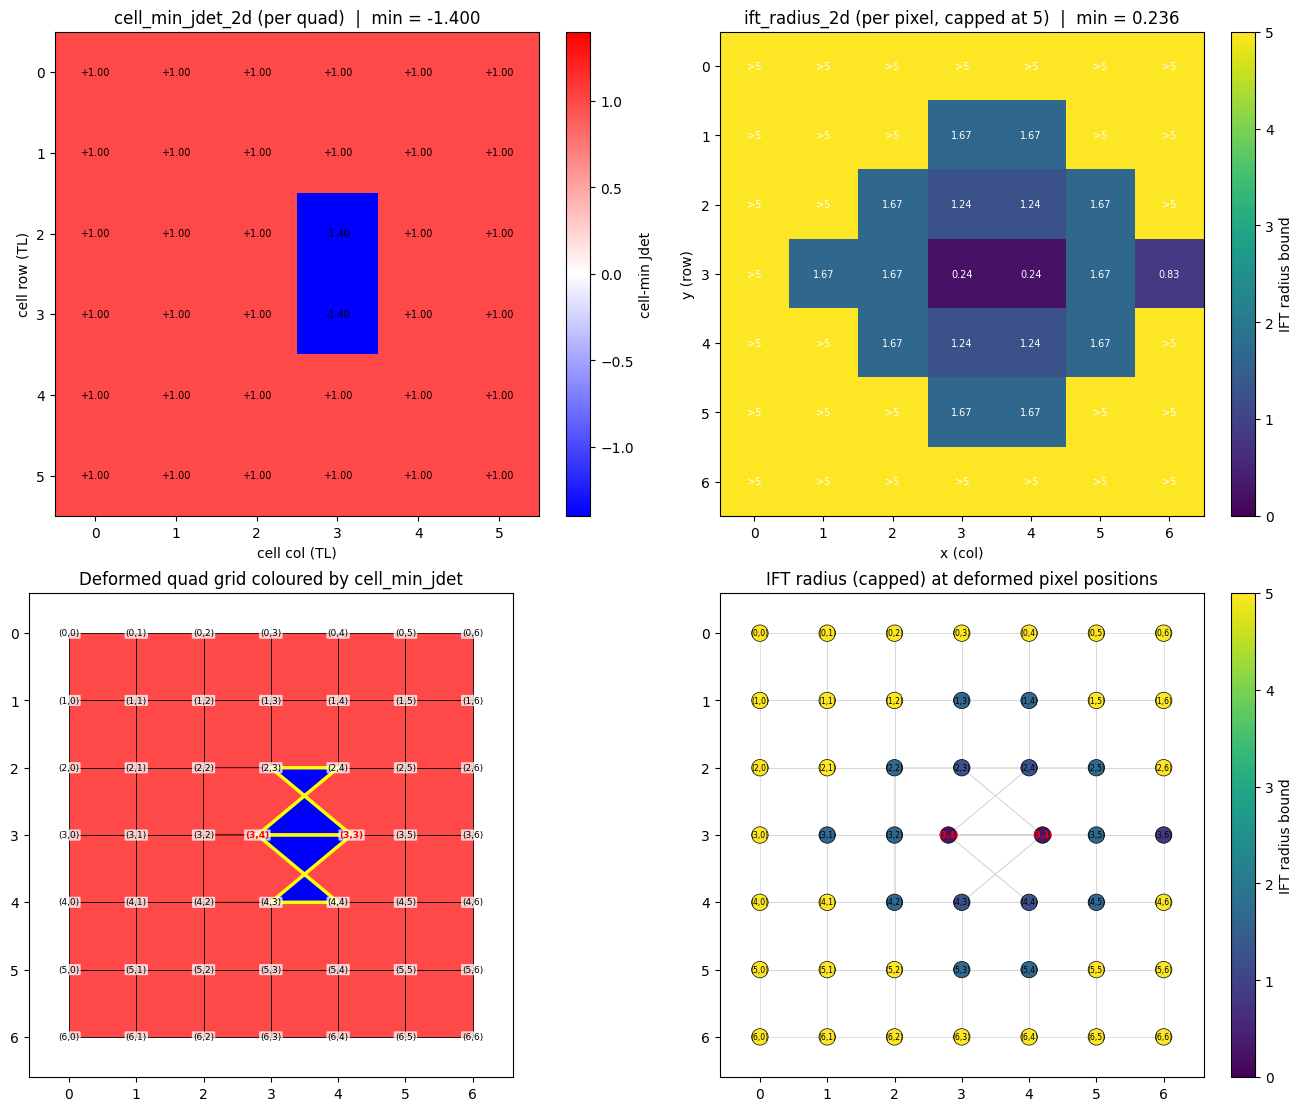

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11), constrained_layout=True)

# ---- top-left: cell_min_jdet heatmap with annotated values -------------
vmax_c = max(abs(cell_min.min()), abs(cell_min.max()), 1.0)
norm_c = mcolors.TwoSlopeNorm(vmin=-vmax_c, vcenter=0, vmax=vmax_c)
im00 = axes[0, 0].imshow(cell_min, cmap="bwr", norm=norm_c)
for (i, j), v in np.ndenumerate(cell_min):
    axes[0, 0].text(j, i, f"{v:+.2f}", ha="center", va="center",
                    fontsize=7, color="black")
axes[0, 0].set_title(f"cell_min_jdet_2d (per quad)  |  min = {cell_min.min():+.3f}")
axes[0, 0].set_xlabel("cell col (TL)")
axes[0, 0].set_ylabel("cell row (TL)")
plt.colorbar(im00, ax=axes[0, 0], label="cell-min Jdet")

# ---- top-right: ift_radius heatmap (capped) with annotated values ------
im01 = axes[0, 1].imshow(ift_display, cmap="viridis", vmin=0, vmax=5.0)
for (i, j), v in np.ndenumerate(ift_r):
    label = ">5" if v >= 5.0 else f"{v:.2f}"
    axes[0, 1].text(j, i, label, ha="center", va="center",
                    fontsize=7, color="white")
axes[0, 1].set_title(f"ift_radius_2d (per pixel, capped at 5)  |  min = {ift_r.min():.3f}")
axes[0, 1].set_xlabel("x (col)")
axes[0, 1].set_ylabel("y (row)")
plt.colorbar(im01, ax=axes[0, 1], label="IFT radius bound")

# ---- bottom-left: cell_min overlaid on deformed quad grid --------------
ax = axes[1, 0]
for i in range(H - 1):
    for j in range(W - 1):
        corners = [
            (def_x[i, j],         def_y[i, j]),
            (def_x[i, j + 1],     def_y[i, j + 1]),
            (def_x[i + 1, j + 1], def_y[i + 1, j + 1]),
            (def_x[i + 1, j],     def_y[i + 1, j]),
        ]
        bad = cell_min[i, j] <= 0
        ax.add_patch(Polygon(
            corners, closed=True,
            facecolor=plt.get_cmap("bwr")(norm_c(cell_min[i, j])),
            edgecolor="yellow" if bad else "black",
            linewidth=2.5 if bad else 0.6,
            zorder=2 if bad else 1,
        ))
_annotate_vertices(ax, def_x, def_y)
ax.set_xlim(def_x.min() - 0.6, def_x.max() + 0.6)
ax.set_ylim(def_y.max() + 0.6, def_y.min() - 0.6)
ax.set_aspect("equal")
ax.set_title("Deformed quad grid coloured by cell_min_jdet")

# ---- bottom-right: ift_radius scatter over deformed pixel positions ----
ax = axes[1, 1]
for i in range(H - 1):
    for j in range(W - 1):
        corners = [
            (def_x[i, j],         def_y[i, j]),
            (def_x[i, j + 1],     def_y[i, j + 1]),
            (def_x[i + 1, j + 1], def_y[i + 1, j + 1]),
            (def_x[i + 1, j],     def_y[i + 1, j]),
        ]
        ax.add_patch(Polygon(corners, closed=True,
                             facecolor="none", edgecolor="lightgray",
                             linewidth=0.5, zorder=0))
sc = ax.scatter(def_x.ravel(), def_y.ravel(),
                c=ift_display.ravel(), cmap="viridis",
                vmin=0, vmax=5.0, s=140, edgecolor="k", linewidth=0.5,
                zorder=3)
for i in range(H):
    for j in range(W):
        moved = (dx[i, j] != 0) or (dy[i, j] != 0)
        ax.text(def_x[i, j], def_y[i, j], f"({i},{j})",
                ha="center", va="center", fontsize=5.5,
                color="red" if moved else "black",
                fontweight="bold" if moved else "normal", zorder=4)
ax.set_xlim(def_x.min() - 0.6, def_x.max() + 0.6)
ax.set_ylim(def_y.max() + 0.6, def_y.min() - 0.6)
ax.set_aspect("equal")
ax.set_title("IFT radius (capped) at deformed pixel positions")
plt.colorbar(sc, ax=ax, label="IFT radius bound")

plt.show()

assert n_bad_cells > 0, "cell_min should flag the bowtie cell"

<a id="sec-correction"></a>
## Correction â€” optimise for positive Jdet **and** positive shoelace

The central-difference pixel Jdet is already everywhere positive, so a solver that constrains only `jacobian_det2D` would accept this field unchanged. By passing `enforce_shoelace=True` to `iterative_serial`, the solver adds the per-quad shoelace area as a second constraint family and actively corrects the bowtie.

`iterative_serial` internally locates the worst-Jdet / negative-shoelace pixel, builds a bounding window of the connected bad region with a 1-pixel positive border, and runs SLSQP on that sub-window with frozen edges (see the CLAUDE.md notes). With only two offending cells the windowed step converges in one pass.

We then re-run every diagnostic from above on the corrected field and compare.

In [10]:
from dvfopt import iterative_serial

phi_corr = iterative_serial(
    deformation,
    enforce_shoelace=True,
    verbose=1,
)                                                # returns (2, H, W): [dy, dx]

dy_corr = phi_corr[0]
dx_corr = phi_corr[1]
deformation_corr = np.zeros_like(deformation)
deformation_corr[1, 0] = dy_corr
deformation_corr[2, 0] = dx_corr

def_y_corr = yy + dy_corr
def_x_corr = xx + dx_corr

print(f"\nmax |Î”dx| vs original: {np.abs(dx_corr - dx).max():.4f}")
print(f"max |Î”dy| vs original: {np.abs(dy_corr - dy).max():.4f}")
moved_pixels = np.argwhere(np.abs(dx_corr - dx) + np.abs(dy_corr - dy) > 1e-8)
print(f"pixels modified by solver: {len(moved_pixels)} -> "
      f"{[tuple(int(v) for v in ij) for ij in moved_pixels]}")

[init] Grid 7x7  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 0  |  min Jdet: 0.400000
[iter    1]  fix (  2,  3)  win 7x6  neg_jdet     0  min_jdet +0.470326  L2 0.2425  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 7 x 7
  Iterations       : 1
  Neg-Jdet      0 ->     0
  Min Jdet  +0.400000 -> +0.470326
  L2 error         : 0.242483
  Time             : 0.01s

max |Î”dx| vs original: 0.1400
max |Î”dy| vs original: 0.0007
pixels modified by solver: 6 -> [(2, 3), (2, 4), (3, 3), (3, 4), (4, 3), (4, 4)]


<a id="sec-requantify"></a>
### Re-quantify the corrected field

We now run every diagnostic used above on `phi_corr` and compare to the pre-correction values.

In [11]:
# --- Pixel Jdet + shoelace on the corrected field -----------------------
jdet_corr = np.squeeze(jacobian_det2D(phi_corr))
shoe_corr = np.squeeze(shoelace_det2D(phi_corr))

# --- Monotonicity diffs --------------------------------------------------
h_mono_c, v_mono_c = _monotonicity_diffs_2d(dy_corr, dx_corr)
d1_c, d2_c = _diagonal_monotonicity_diffs_2d(dy_corr, dx_corr)

# --- Cell-min Jdet + IFT radius -----------------------------------------
cell_min_corr = cell_min_jdet_2d(phi_corr)
ift_r_corr    = ift_radius_2d(phi_corr)


def _row(name, orig, corr, fmt="{:+.4f}"):
    return (f"  {name:<24s}  "
            f"{fmt.format(orig):>10s}   ->   {fmt.format(corr):>10s}")


print("Before / after comparison (min values):\n")
print(_row("pixel Jdet (central)",  jdet.min(),        jdet_corr.min()))
print(_row("shoelace area",         shoe.min(),        shoe_corr.min()))
print(_row("h_mono",                h_mono.min(),      h_mono_c.min()))
print(_row("v_mono",                v_mono.min(),      v_mono_c.min()))
print(_row("d1 (diag)",             d1.min(),          d1_c.min()))
print(_row("d2 (diag)",             d2.min(),          d2_c.min()))
print(_row("cell_min_jdet",         cell_min.min(),    cell_min_corr.min()))
print(_row("ift_radius",            ift_r.min(),       ift_r_corr.min(),
           fmt="{:.4f}"))

print("\nCounts of non-positive entries (before -> after):")
print(_row("pixel Jdet neg",        (jdet <= 0).sum(),
                                    (jdet_corr <= 0).sum(), fmt="{:d}"))
print(_row("shoelace neg",          (shoe <= 0).sum(),
                                    (shoe_corr <= 0).sum(), fmt="{:d}"))
print(_row("cell_min_jdet neg",     (cell_min <= 0).sum(),
                                    (cell_min_corr <= 0).sum(), fmt="{:d}"))
print(_row("h_mono neg",            (h_mono <= 0).sum(),
                                    (h_mono_c <= 0).sum(), fmt="{:d}"))

# --- What the enforced constraints actually guarantee -------------------
# The solver was asked for positive pixel Jdet + positive shoelace; those
# are what we can assert. The stronger edge-wise conditions (cell_min_jdet,
# h_mono) require `enforce_injectivity=True` — see discussion below.
assert (jdet_corr > 0).all(), "central-diff pixel Jdet must be positive"
assert (shoe_corr > 0).all(), "shoelace areas must be positive"

if (cell_min_corr > 0).all():
    print("\nBonus: cell_min_jdet_2d is also fully positive — the shoelace "
          "constraint happened to certify sub-pixel injectivity here.")
else:
    n_bad = int((cell_min_corr <= 0).sum())
    print(f"\nNote: {n_bad} cell(s) still fail cell_min_jdet_2d > 0. "
          "Shoelace positivity (signed area) is strictly weaker than "
          "edge-wise monotonicity / bilinear positivity — a quad can "
          "have positive net area while one edge still crosses. To close "
          "this gap, pass `enforce_injectivity=True` to the solver.")

Before / after comparison (min values):

  pixel Jdet (central)         +0.4000   ->      +0.4703
  shoelace area                -0.2000   ->      +0.0100
  h_mono                       -1.4000   ->      -1.1200
  v_mono                       +1.0000   ->      +0.9993
  d1 (diag)                    -0.2000   ->      +0.0100
  d2 (diag)                    +1.0000   ->      +0.9993
  cell_min_jdet                -1.4000   ->      -1.1208
  ift_radius                    0.2357   ->       0.3135

Counts of non-positive entries (before -> after):
  pixel Jdet neg                     0   ->            0
  shoelace neg                       2   ->            0
  cell_min_jdet neg                  2   ->            2
  h_mono neg                         1   ->            1

Note: 2 cell(s) still fail cell_min_jdet_2d > 0. Shoelace positivity (signed area) is strictly weaker than edge-wise monotonicity / bilinear positivity — a quad can have positive net area while one edge still crosses. To cl

<a id="sec-beforeafter"></a>
### Before / after â€” quad grid and diagnostic heatmaps

Left column is the **pre-correction** bowtie; right column is the **post-correction** field. Top row: deformed quads coloured by shoelace area (folded cells outlined yellow). Middle row: per-cell `cell_min_jdet_2d` (the bilinear sub-pixel injectivity certificate). Bottom row: per-pixel `ift_radius_2d` at deformed vertex positions (capped at 5.0 for display â€” constant regions produce `1/Îµ`).

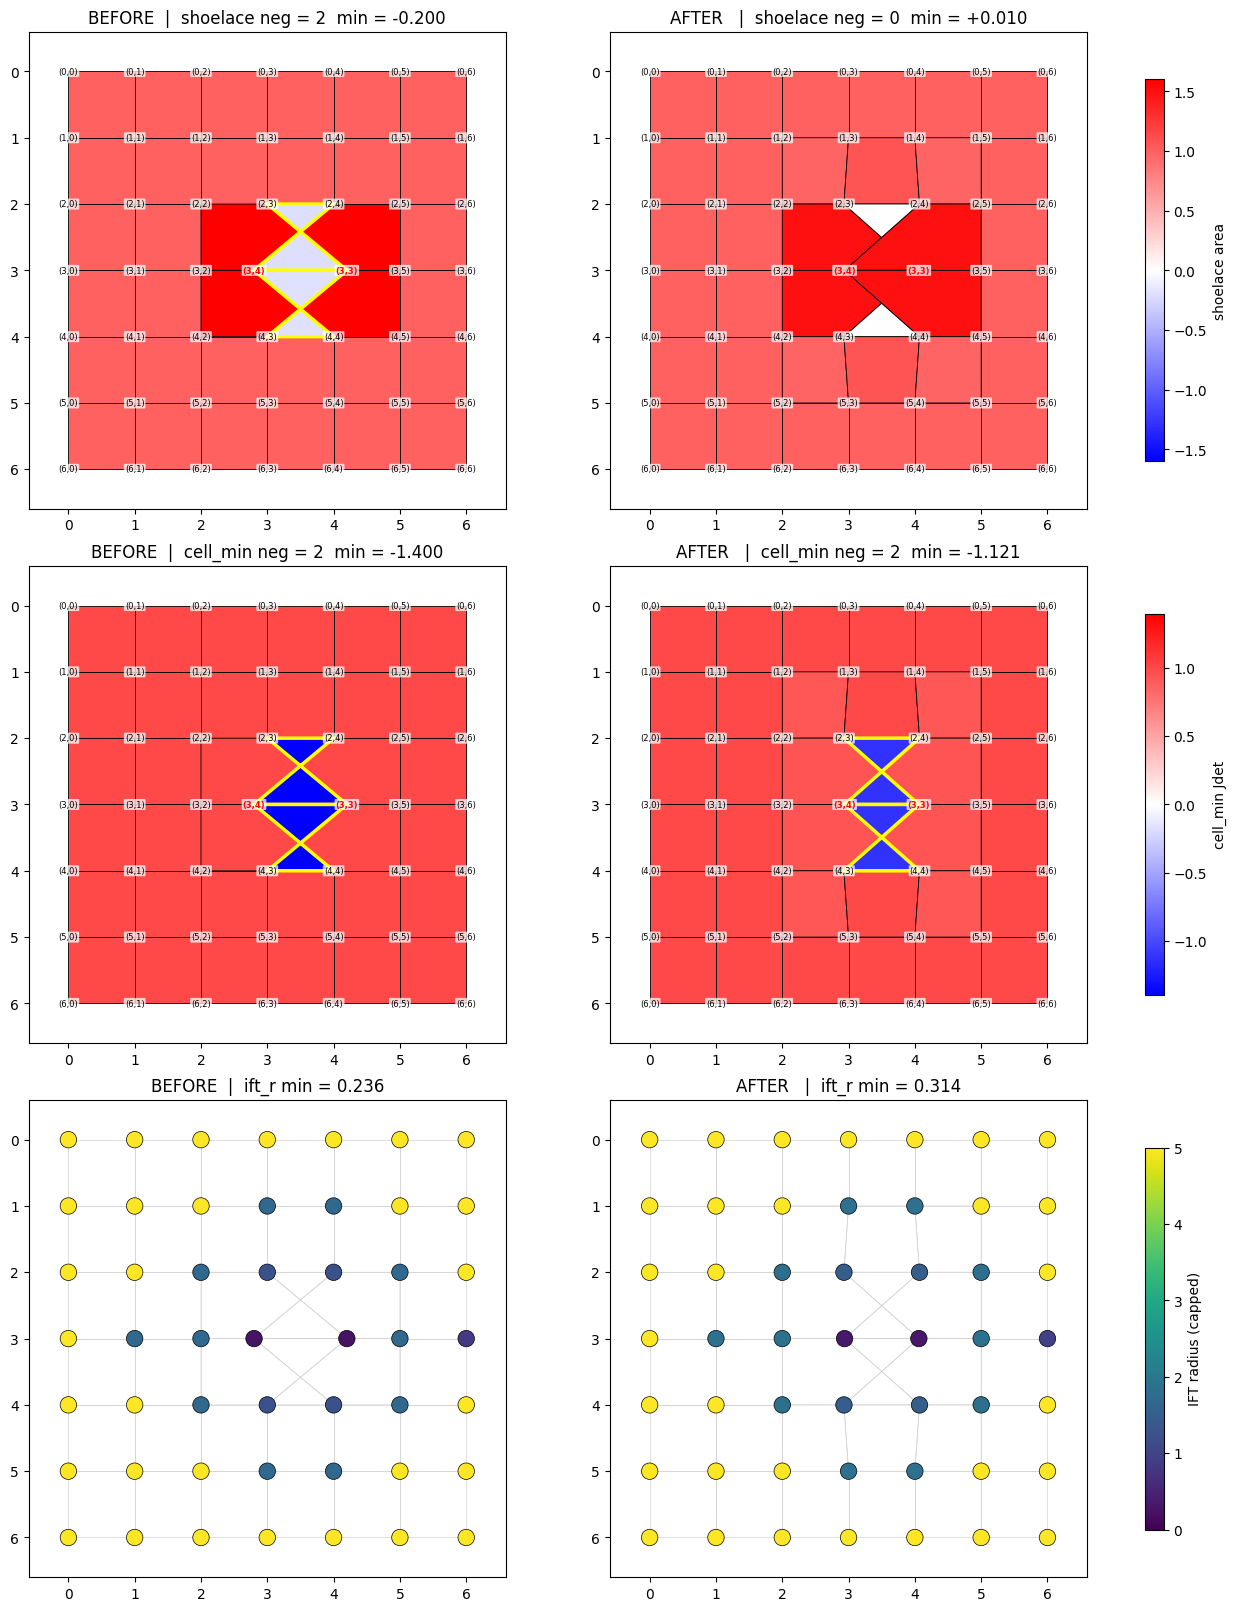

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(13, 16), constrained_layout=True)

cmap = plt.get_cmap("bwr")

# Shared shoelace normalisation so both panels are directly comparable.
vmax_s = max(abs(shoe.min()), abs(shoe.max()),
             abs(shoe_corr.min()), abs(shoe_corr.max()), 1.0)
norm_s = mcolors.TwoSlopeNorm(vmin=-vmax_s, vcenter=0, vmax=vmax_s)

# Shared cell_min normalisation.
vmax_c = max(abs(cell_min.min()), abs(cell_min.max()),
             abs(cell_min_corr.min()), abs(cell_min_corr.max()), 1.0)
norm_c = mcolors.TwoSlopeNorm(vmin=-vmax_c, vcenter=0, vmax=vmax_c)


def _draw_shoelace_quads(ax, dxg, dyg, shoe_vals, title):
    xg = xx + dxg
    yg = yy + dyg
    for i in range(H - 1):
        for j in range(W - 1):
            corners = [
                (xg[i, j],         yg[i, j]),
                (xg[i, j + 1],     yg[i, j + 1]),
                (xg[i + 1, j + 1], yg[i + 1, j + 1]),
                (xg[i + 1, j],     yg[i + 1, j]),
            ]
            bad = shoe_vals[i, j] <= 0
            ax.add_patch(Polygon(
                corners, closed=True,
                facecolor=cmap(norm_s(shoe_vals[i, j])),
                edgecolor="yellow" if bad else "black",
                linewidth=2.5 if bad else 0.6,
                zorder=2 if bad else 1,
            ))
    _annotate_vertices(ax, xg, yg, fontsize=6)
    ax.set_xlim(min(xg.min(), def_x.min()) - 0.6, max(xg.max(), def_x.max()) + 0.6)
    ax.set_ylim(max(yg.max(), def_y.max()) + 0.6, min(yg.min(), def_y.min()) - 0.6)
    ax.set_aspect("equal")
    ax.set_title(title)


def _draw_cell_min_quads(ax, dxg, dyg, cellmin_vals, title):
    xg = xx + dxg
    yg = yy + dyg
    for i in range(H - 1):
        for j in range(W - 1):
            corners = [
                (xg[i, j],         yg[i, j]),
                (xg[i, j + 1],     yg[i, j + 1]),
                (xg[i + 1, j + 1], yg[i + 1, j + 1]),
                (xg[i + 1, j],     yg[i + 1, j]),
            ]
            bad = cellmin_vals[i, j] <= 0
            ax.add_patch(Polygon(
                corners, closed=True,
                facecolor=cmap(norm_c(cellmin_vals[i, j])),
                edgecolor="yellow" if bad else "black",
                linewidth=2.5 if bad else 0.6,
                zorder=2 if bad else 1,
            ))
    _annotate_vertices(ax, xg, yg, fontsize=6)
    ax.set_xlim(min(xg.min(), def_x.min()) - 0.6, max(xg.max(), def_x.max()) + 0.6)
    ax.set_ylim(max(yg.max(), def_y.max()) + 0.6, min(yg.min(), def_y.min()) - 0.6)
    ax.set_aspect("equal")
    ax.set_title(title)


def _draw_ift_scatter(ax, dxg, dyg, ift_vals, title):
    xg = xx + dxg
    yg = yy + dyg
    for i in range(H - 1):
        for j in range(W - 1):
            corners = [
                (xg[i, j],         yg[i, j]),
                (xg[i, j + 1],     yg[i, j + 1]),
                (xg[i + 1, j + 1], yg[i + 1, j + 1]),
                (xg[i + 1, j],     yg[i + 1, j]),
            ]
            ax.add_patch(Polygon(corners, closed=True, facecolor="none",
                                 edgecolor="lightgray", linewidth=0.5, zorder=0))
    ift_capped = np.clip(ift_vals, 0, 5.0)
    sc = ax.scatter(xg.ravel(), yg.ravel(),
                    c=ift_capped.ravel(), cmap="viridis",
                    vmin=0, vmax=5.0, s=140,
                    edgecolor="k", linewidth=0.5, zorder=3)
    ax.set_xlim(min(xg.min(), def_x.min()) - 0.6, max(xg.max(), def_x.max()) + 0.6)
    ax.set_ylim(max(yg.max(), def_y.max()) + 0.6, min(yg.min(), def_y.min()) - 0.6)
    ax.set_aspect("equal")
    ax.set_title(title)
    return sc


# ---- row 1: shoelace fills ---------------------------------------------
_draw_shoelace_quads(axes[0, 0], dx,      dy,      shoe,
                     f"BEFORE  |  shoelace neg = {(shoe<=0).sum()}  "
                     f"min = {shoe.min():+.3f}")
_draw_shoelace_quads(axes[0, 1], dx_corr, dy_corr, shoe_corr,
                     f"AFTER   |  shoelace neg = {(shoe_corr<=0).sum()}  "
                     f"min = {shoe_corr.min():+.3f}")
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_s),
             ax=axes[0, :], label="shoelace area", shrink=0.8)

# ---- row 2: cell_min fills ---------------------------------------------
_draw_cell_min_quads(axes[1, 0], dx,      dy,      cell_min,
                     f"BEFORE  |  cell_min neg = {(cell_min<=0).sum()}  "
                     f"min = {cell_min.min():+.3f}")
_draw_cell_min_quads(axes[1, 1], dx_corr, dy_corr, cell_min_corr,
                     f"AFTER   |  cell_min neg = {(cell_min_corr<=0).sum()}  "
                     f"min = {cell_min_corr.min():+.3f}")
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_c),
             ax=axes[1, :], label="cell_min Jdet", shrink=0.8)

# ---- row 3: IFT radius scatter -----------------------------------------
sc0 = _draw_ift_scatter(axes[2, 0], dx,      dy,      ift_r,
                        f"BEFORE  |  ift_r min = {ift_r.min():.3f}")
sc1 = _draw_ift_scatter(axes[2, 1], dx_corr, dy_corr, ift_r_corr,
                        f"AFTER   |  ift_r min = {ift_r_corr.min():.3f}")
fig.colorbar(sc1, ax=axes[2, :], label="IFT radius (capped)", shrink=0.8)

plt.show()

<a id="sec-triangulated"></a>
## Strengthening — triangulated shoelace closes the bowtie loophole

The plain shoelace constraint failed to unfold the bowtie because the shoelace area is the **signed net area** of a quad: if one lobe of a bowtie is larger than the other, the net area is still positive even though the quad self-intersects.

<a id="sec-tri-intuition"></a>
### Enhanced shoelace constraint — setup and formula

**Setup.** For each grid cell $(r, c)$, the four deformed corners are

$$
\begin{aligned}
\mathrm{TL} &= (\,c + dx[r, c],\ \ r + dy[r, c]\,) \\
\mathrm{TR} &= (\,c + 1 + dx[r, c+1],\ \ r + dy[r, c+1]\,) \\
\mathrm{BR} &= (\,c + 1 + dx[r+1, c+1],\ \ r + 1 + dy[r+1, c+1]\,) \\
\mathrm{BL} &= (\,c + dx[r+1, c],\ \ r + 1 + dy[r+1, c]\,).
\end{aligned}
$$

Write $(x_k, y_k)$ for $k \in \{\mathrm{TL}, \mathrm{TR}, \mathrm{BR}, \mathrm{BL}\}$ below.

**Plain shoelace (what failed).** The signed area of the deformed quad is

$$
A_{\mathrm{quad}} \;=\; \tfrac{1}{2}\,\bigl[\,(x_0 y_1 - x_1 y_0) + (x_1 y_2 - x_2 y_1) + (x_2 y_3 - x_3 y_2) + (x_3 y_0 - x_0 y_3)\,\bigr],
$$

with the corners ordered TL → TR → BR → BL. Requiring $A_{\mathrm{quad}} > 0$ catches most folds, but a self-intersecting bowtie has two lobes of opposite orientation that cancel in this sum — so an asymmetric bowtie can satisfy $A_{\mathrm{quad}} > 0$ while still crossing itself.

**Triangulated formulation (what we use).** Split each quad along its TL → BR diagonal into two triangles, and require *each* triangle to have positive signed area separately. Using the 2-D cross-product form (twice the signed triangle area):

$$
\begin{aligned}
T_1(r, c) &= \tfrac{1}{2}\,\bigl[\,(x_{\mathrm{TR}} - x_{\mathrm{TL}})(y_{\mathrm{BR}} - y_{\mathrm{TL}}) \;-\; (x_{\mathrm{BR}} - x_{\mathrm{TL}})(y_{\mathrm{TR}} - y_{\mathrm{TL}})\,\bigr], \\[2pt]
T_2(r, c) &= \tfrac{1}{2}\,\bigl[\,(x_{\mathrm{BR}} - x_{\mathrm{TL}})(y_{\mathrm{BL}} - y_{\mathrm{TL}}) \;-\; (x_{\mathrm{BL}} - x_{\mathrm{TL}})(y_{\mathrm{BR}} - y_{\mathrm{TL}})\,\bigr].
\end{aligned}
$$

By construction $A_{\mathrm{quad}} = T_1 + T_2$, so the triangulated constraint is strictly stronger than the plain shoelace.

**The SLSQP constraint.** For every cell $(r, c)$ in the sub-window and a threshold $\tau$ (default $10^{-2}$),

$$
T_1(r, c) \;\geq\; \tau \qquad \text{and} \qquad T_2(r, c) \;\geq\; \tau.
$$

These two inequality families are added to the optimiser alongside the usual $\mathrm{Jdet} \geq \tau$, with an analytic sparse Jacobian (six non-zeros per row — three $dx$'s and three $dy$'s, since each triangle touches only three of the four corners).

**Why this works in plain English.**

* Each triangle's signed area is a 2-D cross product of two edges. Its sign is the orientation of the triangle (counter-clockwise = positive). There is no second lobe to cancel against, so a negative value is an unambiguous certificate that the three corners have been twisted out of order.
* A quad with both $T_1 > 0$ and $T_2 > 0$ has **every** triangle (and therefore every edge of those triangles) in its original orientation, so nothing has crossed. The asymmetric-bowtie loophole — positive net area but one lobe flipped — is closed because the flipped lobe is now one of the triangles, and it must be positive on its own.
* The diagonal split is arbitrary (we pick TL → BR); any fixed diagonal choice works because a planar quad self-intersects iff at least one of its two diagonals produces a flipped triangle, and the TL → BR split flips iff the quad fails.

This is exposed as `enforce_shoelace_triangulated=True` on `iterative_serial`, backed by `triangulated_shoelace_det2D` and `triangulated_shoelace_constraint_jacobian_2d`.

[↑ Back to TOC](#sec-toc)

In [13]:
phi_tri = iterative_serial(
    deformation,
    enforce_shoelace_triangulated=True,
    verbose=1,
)

dy_tri = phi_tri[0]
dx_tri = phi_tri[1]
def_y_tri = yy + dy_tri
def_x_tri = xx + dx_tri

print(f"\nmax |delta dx| vs original: {np.abs(dx_tri - dx).max():.4f}")
print(f"max |delta dy| vs original: {np.abs(dy_tri - dy).max():.4f}")

[init] Grid 7x7  |  threshold=0.01  |  method=SLSQP
[init] Neg-Jdet pixels: 0  |  min Jdet: 0.400000
[iter    1]  fix (  2,  3)  win 7x6  neg_jdet     0  min_jdet +0.596138  L2 0.8527  sub-iters 1
[done] All Jdet > threshold after iter 1

  SUMMARY  (SLSQP)
------------------------------------------------------------
  Grid size        : 7 x 7
  Iterations       : 1
  Neg-Jdet      0 ->     0
  Min Jdet  +0.400000 -> +0.596138
  L2 error         : 0.852674
  Time             : 0.02s

max |delta dx| vs original: 0.4433
max |delta dy| vs original: 0.3448


<a id="sec-tri-requantify"></a>
### Re-quantify the triangulated correction

Run every diagnostic on `phi_tri` and compare to both the pre-correction bowtie and the plain-shoelace correction above.

In [14]:
from dvfopt.jacobian import triangulated_shoelace_det2D
from dvfopt.jacobian.intersection import has_quad_self_intersections

# --- Pixel Jdet + shoelace families on the triangulated-corrected field -
jdet_tri  = np.squeeze(jacobian_det2D(phi_tri))
shoe_tri  = np.squeeze(shoelace_det2D(phi_tri))
T1T2_tri  = triangulated_shoelace_det2D(phi_tri)           # (2, H-1, W-1)
T1_tri, T2_tri = T1T2_tri[0], T1T2_tri[1]

# Monotonicity + cell-min + IFT radius.
h_mono_t, v_mono_t = _monotonicity_diffs_2d(dy_tri, dx_tri)
d1_t, d2_t         = _diagonal_monotonicity_diffs_2d(dy_tri, dx_tri)
cell_min_tri       = cell_min_jdet_2d(phi_tri)
ift_r_tri          = ift_radius_2d(phi_tri)


def _row3(name, orig, shoe_only, tri, fmt="{:+.4f}"):
    def f(v):
        if isinstance(v, float) and np.isnan(v):
            return "        --"
        return fmt.format(v)
    return f"  {name:<22s}  {f(orig):>10s}   {f(shoe_only):>10s}   {f(tri):>10s}"


print(f"  {'measure':<22s}  {'bowtie':>10s}   {'shoelace':>10s}   {'triangulated':>10s}")
print("  " + "-" * 70)
print(_row3("pixel Jdet (central)", jdet.min(),      jdet_corr.min(),     jdet_tri.min()))
print(_row3("shoelace area",        shoe.min(),      shoe_corr.min(),     shoe_tri.min()))
print(_row3("T1 (upper triangle)",  float("nan"),    float("nan"),        float(T1_tri.min())))
print(_row3("T2 (lower triangle)",  float("nan"),    float("nan"),        float(T2_tri.min())))
print(_row3("h_mono",               h_mono.min(),    h_mono_c.min(),      h_mono_t.min()))
print(_row3("v_mono",               v_mono.min(),    v_mono_c.min(),      v_mono_t.min()))
print(_row3("d1 (diag)",            d1.min(),        d1_c.min(),          d1_t.min()))
print(_row3("d2 (diag)",            d2.min(),        d2_c.min(),          d2_t.min()))
print(_row3("cell_min_jdet",        cell_min.min(), cell_min_corr.min(), cell_min_tri.min()))
print(_row3("ift_radius",           ift_r.min(),     ift_r_corr.min(),    ift_r_tri.min(),
            fmt="{:.4f}"))

print("\nCounts of non-positive entries (bowtie -> shoelace -> triangulated):")
print(_row3("pixel Jdet neg",       int((jdet <= 0).sum()),
                                    int((jdet_corr <= 0).sum()),
                                    int((jdet_tri <= 0).sum()), fmt="{:d}"))
print(_row3("shoelace neg",         int((shoe <= 0).sum()),
                                    int((shoe_corr <= 0).sum()),
                                    int((shoe_tri <= 0).sum()), fmt="{:d}"))
print(_row3("cell_min_jdet neg",    int((cell_min <= 0).sum()),
                                    int((cell_min_corr <= 0).sum()),
                                    int((cell_min_tri <= 0).sum()), fmt="{:d}"))
print(_row3("T1 neg",               float("nan"),   float("nan"),
                                    int((T1_tri <= 0).sum()), fmt="{:d}"))
print(_row3("T2 neg",               float("nan"),   float("nan"),
                                    int((T2_tri <= 0).sum()), fmt="{:d}"))

# Hard checks on what enforce_shoelace_triangulated guarantees:
assert (jdet_tri > 0).all(),                   "central-diff pixel Jdet must be positive"
assert (T1_tri  > 0).all(),                    "every T1 triangle must be positive"
assert (T2_tri  > 0).all(),                    "every T2 triangle must be positive"
assert (shoe_tri > 0).all(),                   "shoelace = T1 + T2 > 0 follows from tri > 0"
assert not has_quad_self_intersections(phi_tri), "deformed quad grid must be intersection-free"
print("\nAll triangulated assertions pass - the bowtie is fully unfolded.")

  measure                     bowtie     shoelace   triangulated
  ----------------------------------------------------------------------
  pixel Jdet (central)       +0.4000      +0.4703      +0.5961
  shoelace area              -0.2000      +0.0100      +0.3457
  T1 (upper triangle)             --           --      +0.0100
  T2 (lower triangle)             --           --      +0.0100
  h_mono                     -1.4000      -1.1200      -0.5133
  v_mono                     +1.0000      +0.9993      +0.6552
  d1 (diag)                  -0.2000      +0.0100      +0.2433
  d2 (diag)                  +1.0000      +0.9993      +0.6552
  cell_min_jdet              -1.4000      -1.1208      -0.8581
  ift_radius                  0.2357       0.3135       0.5308

Counts of non-positive entries (bowtie -> shoelace -> triangulated):
  pixel Jdet neg                   0            0            0
  shoelace neg                     2            0            0
  cell_min_jdet neg                2

<a id="sec-tri-beforeafter"></a>
### Before / after — triangulated

Three columns: pre-correction bowtie, plain-shoelace correction, triangulated correction.
Top row: quads coloured by shoelace area. Middle row: per-cell `cell_min_jdet_2d` in the
first two columns, per-cell `min(T1, T2)` in the triangulated column (the metric the
constraint actually enforced). Bottom row: per-vertex central-difference pixel Jdet
scattered over the deformed quad wireframe — unchanged sign across all three variants,
reminding us that pixel Jdet alone can't distinguish the cases.

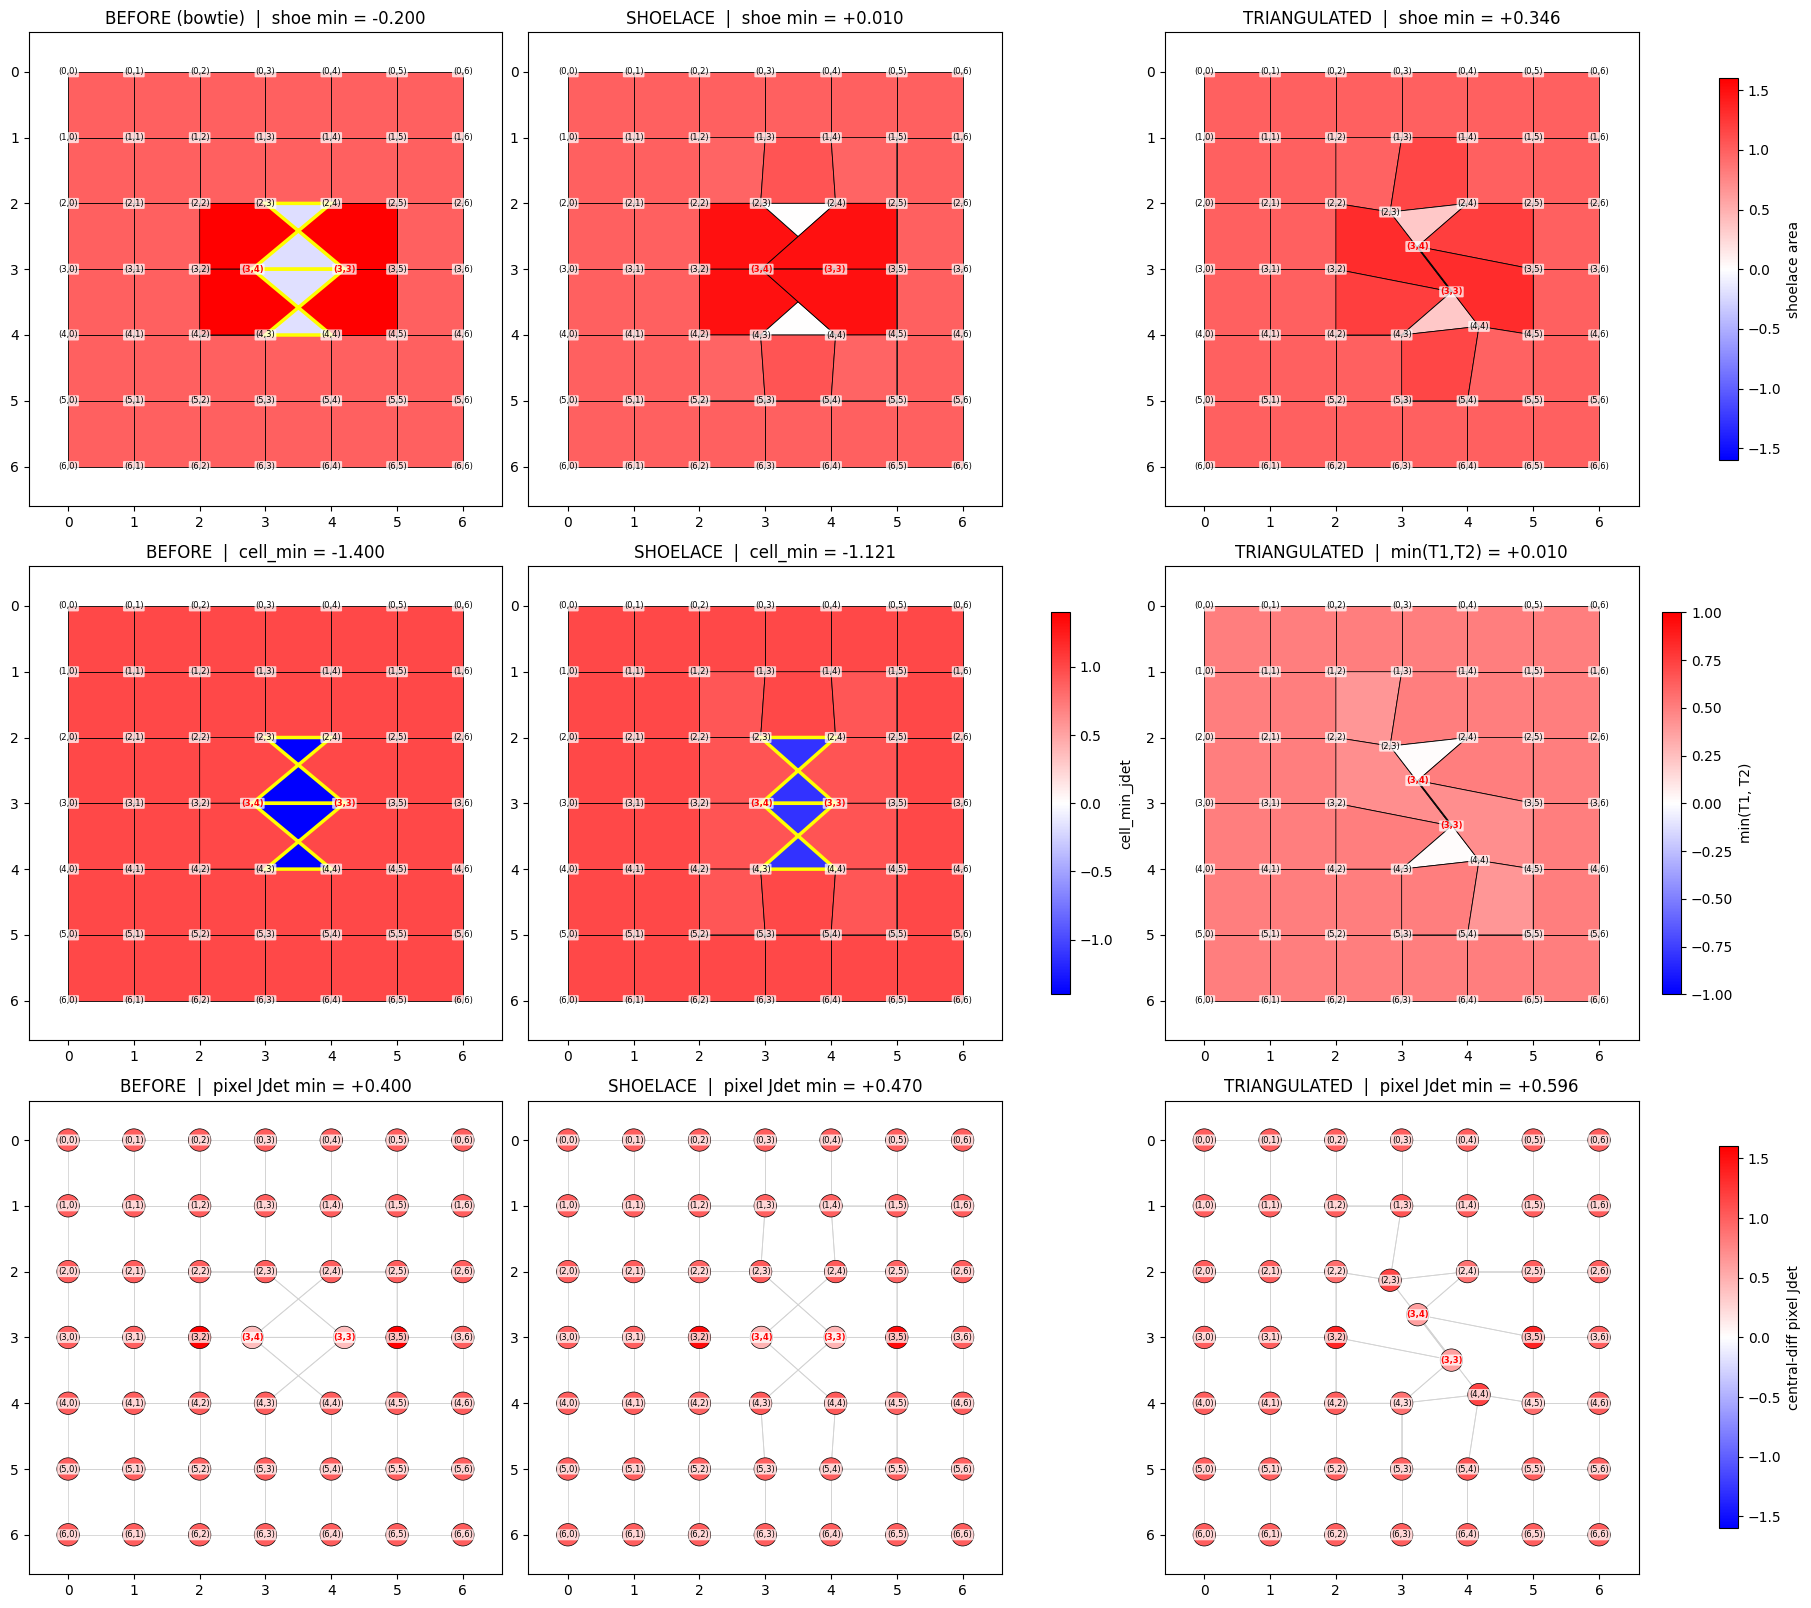

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16), constrained_layout=True)

cmap = plt.get_cmap("bwr")

# Shared norms so the three columns are directly comparable.
vmax_s3 = max(abs(shoe.min()), abs(shoe.max()),
              abs(shoe_corr.min()), abs(shoe_corr.max()),
              abs(shoe_tri.min()), abs(shoe_tri.max()), 1.0)
norm_s3 = mcolors.TwoSlopeNorm(vmin=-vmax_s3, vcenter=0, vmax=vmax_s3)

vmax_c3 = max(abs(cell_min.min()), abs(cell_min.max()),
              abs(cell_min_corr.min()), abs(cell_min_corr.max()),
              abs(cell_min_tri.min()), abs(cell_min_tri.max()), 1.0)
norm_c3 = mcolors.TwoSlopeNorm(vmin=-vmax_c3, vcenter=0, vmax=vmax_c3)

triA = np.minimum(T1_tri, T2_tri)
vmax_t = max(1.0, abs(triA.min()), abs(triA.max()))
norm_t = mcolors.TwoSlopeNorm(vmin=-vmax_t, vcenter=0, vmax=vmax_t)

vmax_j3 = max(abs(jdet.min()), abs(jdet.max()),
              abs(jdet_corr.min()), abs(jdet_corr.max()),
              abs(jdet_tri.min()), abs(jdet_tri.max()), 1.0)
norm_j3 = mcolors.TwoSlopeNorm(vmin=-vmax_j3, vcenter=0, vmax=vmax_j3)

# Shared view window across all panels.
_all_x = np.concatenate([def_x.ravel(), def_x_corr.ravel(), def_x_tri.ravel()])
_all_y = np.concatenate([def_y.ravel(), def_y_corr.ravel(), def_y_tri.ravel()])
_xlim = (_all_x.min() - 0.6, _all_x.max() + 0.6)
_ylim = (_all_y.max() + 0.6, _all_y.min() - 0.6)


def _draw_quads(ax, dxg, dyg, fill_vals, norm, title, bad_mask=None):
    xg = xx + dxg
    yg = yy + dyg
    for i in range(H - 1):
        for j in range(W - 1):
            corners = [
                (xg[i, j],         yg[i, j]),
                (xg[i, j + 1],     yg[i, j + 1]),
                (xg[i + 1, j + 1], yg[i + 1, j + 1]),
                (xg[i + 1, j],     yg[i + 1, j]),
            ]
            bad = bool(bad_mask[i, j]) if bad_mask is not None else fill_vals[i, j] <= 0
            ax.add_patch(Polygon(
                corners, closed=True,
                facecolor=cmap(norm(fill_vals[i, j])),
                edgecolor="yellow" if bad else "black",
                linewidth=2.5 if bad else 0.6,
                zorder=2 if bad else 1,
            ))
    _annotate_vertices(ax, xg, yg, fontsize=6)
    ax.set_xlim(*_xlim)
    ax.set_ylim(*_ylim)
    ax.set_aspect("equal")
    ax.set_title(title)


def _draw_vertex_jdet(ax, dxg, dyg, jdet_vals, title):
    xg = xx + dxg
    yg = yy + dyg
    for i in range(H - 1):
        for j in range(W - 1):
            corners = [
                (xg[i, j],         yg[i, j]),
                (xg[i, j + 1],     yg[i, j + 1]),
                (xg[i + 1, j + 1], yg[i + 1, j + 1]),
                (xg[i + 1, j],     yg[i + 1, j]),
            ]
            ax.add_patch(Polygon(corners, closed=True, facecolor="none",
                                 edgecolor="lightgray", linewidth=0.6, zorder=1))
    sc = ax.scatter(xg.ravel(), yg.ravel(),
                    c=jdet_vals.ravel(), cmap=cmap, norm=norm_j3,
                    s=260, edgecolor="k", linewidth=0.5, zorder=3)
    _annotate_vertices(ax, xg, yg, fontsize=6)
    ax.set_xlim(*_xlim)
    ax.set_ylim(*_ylim)
    ax.set_aspect("equal")
    ax.set_title(title)
    return sc


# Row 0: shoelace fill.
_draw_quads(axes[0, 0], dx,      dy,      shoe,      norm_s3,
            f"BEFORE (bowtie)  |  shoe min = {shoe.min():+.3f}")
_draw_quads(axes[0, 1], dx_corr, dy_corr, shoe_corr, norm_s3,
            f"SHOELACE  |  shoe min = {shoe_corr.min():+.3f}")
_draw_quads(axes[0, 2], dx_tri,  dy_tri,  shoe_tri,  norm_s3,
            f"TRIANGULATED  |  shoe min = {shoe_tri.min():+.3f}")
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_s3),
             ax=axes[0, :], label="shoelace area", shrink=0.8)

# Row 1: cell_min_jdet on first two panels, min(T1,T2) on the third.
_draw_quads(axes[1, 0], dx,      dy,      cell_min,      norm_c3,
            f"BEFORE  |  cell_min = {cell_min.min():+.3f}")
_draw_quads(axes[1, 1], dx_corr, dy_corr, cell_min_corr, norm_c3,
            f"SHOELACE  |  cell_min = {cell_min_corr.min():+.3f}")
_draw_quads(axes[1, 2], dx_tri,  dy_tri,  triA, norm_t,
            f"TRIANGULATED  |  min(T1,T2) = {triA.min():+.3f}",
            bad_mask=(triA <= 0))
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_c3),
             ax=axes[1, 0:2], label="cell_min_jdet", shrink=0.8)
fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm_t),
             ax=axes[1, 2], label="min(T1, T2)", shrink=0.8)

# Row 2: per-vertex central-diff pixel Jdet.
sc_jdet = _draw_vertex_jdet(axes[2, 0], dx,      dy,      jdet,
                            f"BEFORE  |  pixel Jdet min = {jdet.min():+.3f}")
_draw_vertex_jdet(axes[2, 1], dx_corr, dy_corr, jdet_corr,
                  f"SHOELACE  |  pixel Jdet min = {jdet_corr.min():+.3f}")
_draw_vertex_jdet(axes[2, 2], dx_tri,  dy_tri,  jdet_tri,
                  f"TRIANGULATED  |  pixel Jdet min = {jdet_tri.min():+.3f}")
fig.colorbar(sc_jdet, ax=axes[2, :], label="central-diff pixel Jdet", shrink=0.8)

plt.show()

<a id="sec-summary"></a>
## Summary

### Diagnostic behaviour on the pre-correction bowtie

| Measure                       | Stencil                         | Flags the fold? |
|-------------------------------|---------------------------------|-----------------|
| `jacobian_det2D`              | central differences (pixel)     | **no**          |
| `shoelace_det2D`              | 4-corner signed area (per quad) | yes             |
| Monotonicity diffs (`h/v/d1/d2`) | forward differences          | yes             |
| `cell_min_jdet_2d`            | bilinear corner minimum         | yes             |
| `ift_radius_2d`               | σ_min / Hessian norm            | collapses locally |
| `triangulated_shoelace_det2D` | per-triangle signed areas (TL–BR split) | yes |

A solver that constrains only the central-difference pixel Jdet can accept a folded field.

### Three levels of geometric correction

| Constraint | What it guarantees | Blocks asymmetric bowties? |
|---|---|---|
| `jacobian_det2D > 0`                 | central-difference Jdet positive everywhere | **no** |
| `enforce_shoelace=True`              | per-quad **net** signed area > 0            | **no** (this notebook's headline artefact) |
| `enforce_shoelace_triangulated=True` | both triangle signed areas > 0              | **yes** |
| `enforce_injectivity=True`           | edge-wise monotonicity (h, v, d1, d2) > 0   | yes (strictly stronger: also certifies `cell_min_jdet > 0`) |

**Why triangulated shoelace works.** Shoelace positivity is the *signed net area* of a quad, so an asymmetric bowtie with lobes of unequal area survives it. Splitting each quad along its TL–BR diagonal into triangles $T_1$ and $T_2$ removes the cancellation — each triangle's signed area is a direct orientation test on its three corners. Requiring both positive means every triangle preserves orientation, so no self-intersecting quad can slip through.

The triangulated variant is the minimal strengthening that closes the bowtie loophole while still being polynomial and (unlike full injectivity / monotonicity) purely *cell-local*.

### Takeaway

Pick the constraint by what you need:

* **Only worried about central-diff Jdet sign?** Default solver.
* **Need geometric fold-free quads, fine with rare bowtie survivors?** `enforce_shoelace=True`.
* **Need truly non-self-intersecting quads without the asymmetric-bowtie gap?** `enforce_shoelace_triangulated=True`.
* **Need full sub-pixel bilinear injectivity?** `enforce_injectivity=True`.

[↑ Back to TOC](#sec-toc)